In [7]:
### import libraries
import os
import re
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    TimeDistributed,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.utils import Sequence

In [8]:
#### data set path
train_path = "data/split_new/ddd/train"
val_path   = "data/split_new/ddd/val"
test_path  = "data/split_new/ddd/test"

IMG_SIZE   = 128
SEQ_LEN    = 10
STEP       = 5
BATCH_SIZE = 8
EPOCHS     = 20

print("Train:", train_path)
print("Val  :", val_path)
print("Test :", test_path)

Train: data/split_new/ddd/train
Val  : data/split_new/ddd/val
Test : data/split_new/ddd/test


In [9]:
#### helper functions
def get_prefix(filename):
    return re.match(r"[A-Za-z]+", filename).group()

def get_number(filename):
    return int(re.findall(r"\d+", filename)[0])

def load_image(path):
    
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype("float32") / 255.0
    
    return img

print("Helper functions ready.")

##Used for:

# extracting person ID
# correct numeric sorting
# loading and resizing images

Helper functions ready.


In [10]:
### build person wise sequence meta -data
def build_sequence_metadata(folder_path):

    meta = []

    for class_name in ["drowsy", "non_drowsy"]:

        label = 0 if class_name == "drowsy" else 1

        class_folder = os.path.join(folder_path, class_name)
        files = os.listdir(class_folder)

        groups = {}

        for file in files:

            prefix = get_prefix(file)

            if prefix not in groups:
                groups[prefix] = []

            groups[prefix].append(file)

        for person in groups:

            person_files = sorted(groups[person], key=get_number)

            for i in range(0, len(person_files)-SEQ_LEN+1, STEP):

                seq = person_files[i:i+SEQ_LEN]

                full_paths = [
                    os.path.join(class_folder, x)
                    for x in seq
                ]

                meta.append((full_paths, label, person))

    return meta

print("Metadata function ready.")

Metadata function ready.


In [11]:
### prepare meta data
train_meta = build_sequence_metadata(train_path)
val_meta   = build_sequence_metadata(val_path)
test_meta  = build_sequence_metadata(test_path)

print("Train Sequences:", len(train_meta))
print("Val Sequences  :", len(val_meta))
print("Test Sequences :", len(test_meta))

Train Sequences: 4809
Val Sequences  : 1480
Test Sequences : 1929


In [12]:
### print sequence per person
def count_by_person(meta):

    summary = {}

    for seq_paths, label, person in meta:

        if person not in summary:
            summary[person] = {"drowsy":0, "non":0, "total":0}

        if label == 0:
            summary[person]["drowsy"] += 1
        else:
            summary[person]["non"] += 1

        summary[person]["total"] += 1

    return summary


def show_summary(name, meta):

    summary = count_by_person(meta)

    print("\n====================")
    print(name.upper())
    print("====================")

    for person in sorted(summary.keys()):

        d = summary[person]["drowsy"]
        n = summary[person]["non"]
        t = summary[person]["total"]

        print(
            f"{person:>3} | Drowsy:{d:>3} | Non:{n:>3} | Total:{t:>3}"
        )

show_summary("Train", train_meta)
show_summary("Validation", val_meta)
show_summary("Test", test_meta)


TRAIN
  B | Drowsy: 61 | Non:  0 | Total: 61
  C | Drowsy: 66 | Non:  0 | Total: 66
  F | Drowsy: 81 | Non:  0 | Total: 81
  G | Drowsy: 97 | Non:  0 | Total: 97
  J | Drowsy: 92 | Non:  0 | Total: 92
  K | Drowsy:121 | Non:  0 | Total:121
  L | Drowsy:143 | Non:  0 | Total:143
  M | Drowsy:152 | Non:  0 | Total:152
  N | Drowsy:228 | Non:  0 | Total:228
  O | Drowsy:217 | Non:  0 | Total:217
  P | Drowsy:188 | Non:  0 | Total:188
  Q | Drowsy:111 | Non:  0 | Total:111
  R | Drowsy: 39 | Non:  0 | Total: 39
  S | Drowsy: 96 | Non:  0 | Total: 96
  T | Drowsy:182 | Non:  0 | Total:182
  V | Drowsy:128 | Non:  0 | Total:128
  Y | Drowsy:218 | Non:  0 | Total:218
 ZA | Drowsy:123 | Non:  0 | Total:123
 ZC | Drowsy:267 | Non:  0 | Total:267
  b | Drowsy:  0 | Non: 80 | Total: 80
  c | Drowsy:  0 | Non: 79 | Total: 79
  g | Drowsy:  0 | Non: 20 | Total: 20
  j | Drowsy:  0 | Non:139 | Total:139
  k | Drowsy:  0 | Non:104 | Total:104
  l | Drowsy:  0 | Non: 74 | Total: 74
  m | Drowsy:  0 |

In [13]:
### custom generator
class SequenceGenerator(Sequence):

    def __init__(self, meta, batch_size=8, shuffle=True):

        self.meta = meta
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(meta))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.meta)/self.batch_size)

    def __getitem__(self, idx):

        batch_ids = self.indexes[
            idx*self.batch_size:(idx+1)*self.batch_size
        ]

        X = []
        y = []

        for i in batch_ids:

            seq_paths, label, person = self.meta[i]

            frames = []

            for path in seq_paths:
                frames.append(load_image(path))

            X.append(frames)
            y.append(label)

        return np.array(X), np.array(y)

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indexes)

print("Generator ready.")

Generator ready.


In [14]:
### create generators
train_gen = SequenceGenerator(train_meta, BATCH_SIZE, True)
val_gen   = SequenceGenerator(val_meta, BATCH_SIZE, False)
test_gen  = SequenceGenerator(test_meta, BATCH_SIZE, False)

print("Train Batches:", len(train_gen))
print("Val Batches  :", len(val_gen))
print("Test Batches :", len(test_gen))

Train Batches: 602
Val Batches  : 185
Test Batches : 242


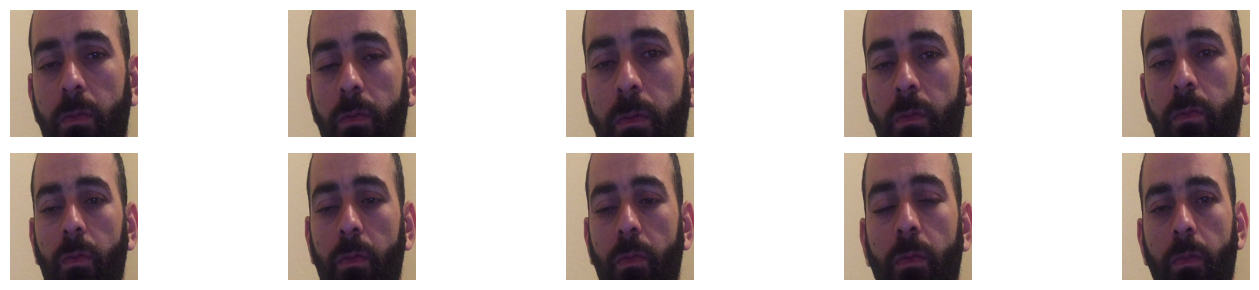

Label: 0


In [15]:
#### visualize one sequence
X_batch, y_batch = train_gen[0]

plt.figure(figsize=(15,3))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(X_batch[0][i])
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Label:", y_batch[0])

In [23]:
### build CNN+LSTM 
model = Sequential()

model.add(TimeDistributed(
    Conv2D(32,(3,3),activation='relu'),
    input_shape=(SEQ_LEN,128,128,3)
))
model.add(TimeDistributed(MaxPooling2D(2,2)))
model.add(TimeDistributed(BatchNormalization()))

model.add(TimeDistributed(
    Conv2D(64,(3,3),activation='relu')
))
model.add(TimeDistributed(MaxPooling2D(2,2)))
model.add(TimeDistributed(BatchNormalization()))

model.add(TimeDistributed(
    Conv2D(128,(3,3),activation='relu')
))
model.add(TimeDistributed(MaxPooling2D(2,2)))
model.add(TimeDistributed(BatchNormalization()))

model.add(TimeDistributed(Flatten()))

model.add(LSTM(128))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/home/anirbannayak/DL_PROJECT/dl-venv/lib/python3.10/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1776494959.194074  145672 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776494959.287761  142743 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 10, 126, 126,   │           896 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 63, 63, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 63, 63, 32) │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 61, 61, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 30, 30, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 10, 30, 30, 64) │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 10, 28, 28,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 10, 14, 14,     │             0 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 10, 14, 14,     │           512 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 10, 25088)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │    12,911,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,013,569 (49.64 MB)

 Trainable params: 13,013,121 (49.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
### call backs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4
)

print("Callbacks ready.")

Callbacks ready.


In [27]:
## model training
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
602/602 ━━━━━━━━━━━━━━━━━━━━ 1240s 2s/step - accuracy: 0.8702 - loss: 0.3100 - val_accuracy: 0.7736 - val_loss: 0.6593 - learning_rate: 0.0010
Epoch 2/20
602/602 ━━━━━━━━━━━━━━━━━━━━ 1248s 2s/step - accuracy: 0.9420 - loss: 0.1457 - val_accuracy: 0.7007 - val_loss: 1.0230 - learning_rate: 0.0010
Epoch 3/20
602/602 ━━━━━━━━━━━━━━━━━━━━ 1251s 2s/step - accuracy: 0.9603 - loss: 0.1062 - val_accuracy: 0.8007 - val_loss: 1.0698 - learning_rate: 0.0010
Epoch 4/20
602/602 ━━━━━━━━━━━━━━━━━━━━ 1257s 2s/step - accuracy: 0.9805 - loss: 0.0584 - val_accuracy: 0.3899 - val_loss: 2.4754 - learning_rate: 0.0010
Epoch 5/20
602/602 ━━━━━━━━━━━━━━━━━━━━ 1254s 2s/step - accuracy: 0.9881 - loss: 0.0367 - val_accuracy: 0.7595 - val_loss: 1.2459 - learning_rate: 5.0000e-04
Epoch 6/20
602/602 ━━━━━━━━━━━━━━━━━━━━ 1255s 2s/step - accuracy: 0.9965 - loss: 0.0140 - val_accuracy: 0.7095 - val_loss: 1.5655 - learning_rate: 5.0000e-04


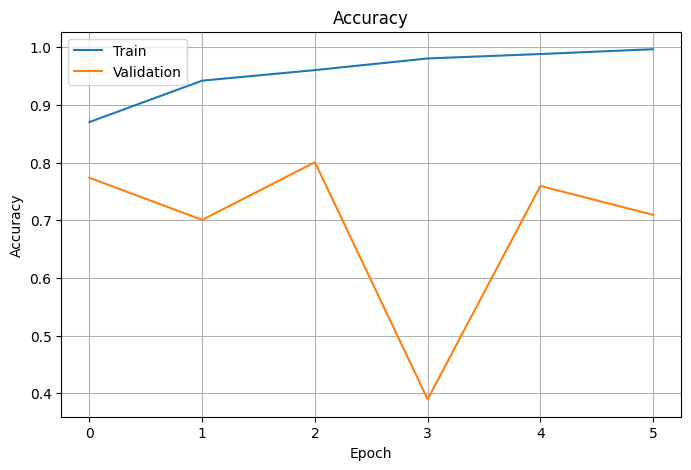

In [28]:
### accuracy plot
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

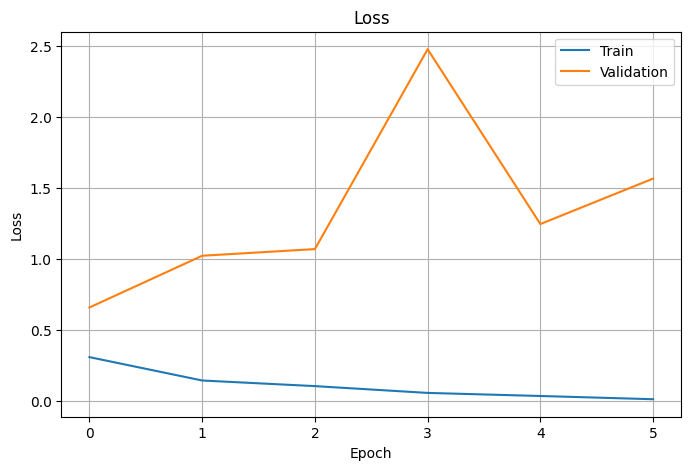

In [29]:
#### loss plot
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
model.save("cnn_lstm_final.h5")

print("Model saved successfully.")

Model saved successfully.


### inference

In [32]:
test_persons = {}

for seq_paths, label, person in test_meta:

    if person not in test_persons:
        test_persons[person] = []

    test_persons[person].append((seq_paths, label))

print("Total Test Persons:", len(test_persons))
print("Persons:", list(test_persons.keys()))

Total Test Persons: 10
Persons: ['X', 'I', 'D', 'A', 'U', 'd', 'x', 'i', 'a', 'u']


In [32]:
for person in test_persons:
    print(person, ":", len(test_persons[person]), "sequences")

X : 344 sequences
I : 216 sequences
D : 34 sequences
A : 279 sequences
U : 82 sequences
d : 196 sequences
x : 226 sequences
i : 205 sequences
a : 247 sequences
u : 100 sequences


In [33]:
## sequential person testing function
def predict_person(person):

    seq_data = test_persons[person]

    X = []
    y = []

    for seq_paths, label in seq_data:

        frames = []

        for path in seq_paths:
            frames.append(load_image(path))

        X.append(frames)
        y.append(label)

    X = np.array(X)
    y = np.array(y)

    probs = model.predict(X, batch_size=BATCH_SIZE).flatten()
    preds = (probs > 0.5).astype(int)

    return X, y, probs, preds

print("Prediction function ready.")

Prediction function ready.


In [41]:
## test one person example
person_name = list(test_persons.keys())[5]

X, y, probs, preds = predict_person(person_name)

print("Person:", person_name)
print("Total Sequences:", len(y))
print("First 10 Predictions:", preds[:10])

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step
Person: d
Total Sequences: 196
First 10 Predictions: [0 0 0 0 0 1 0 1 1 0]


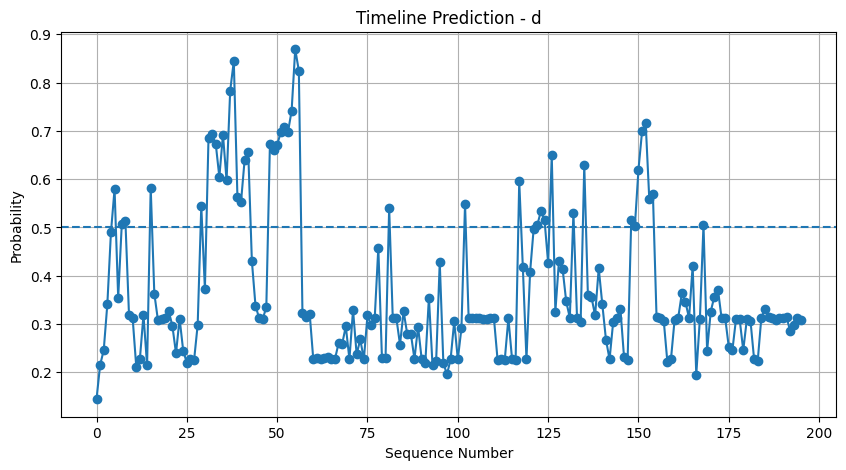

In [43]:
### time line probability plot
plt.figure(figsize=(10,5))

plt.plot(probs, marker='o')
plt.axhline(0.5, linestyle='--')

plt.title(f"Timeline Prediction - {person_name}")
plt.xlabel("Sequence Number")
plt.ylabel("Probability")

plt.grid(True)
plt.show()

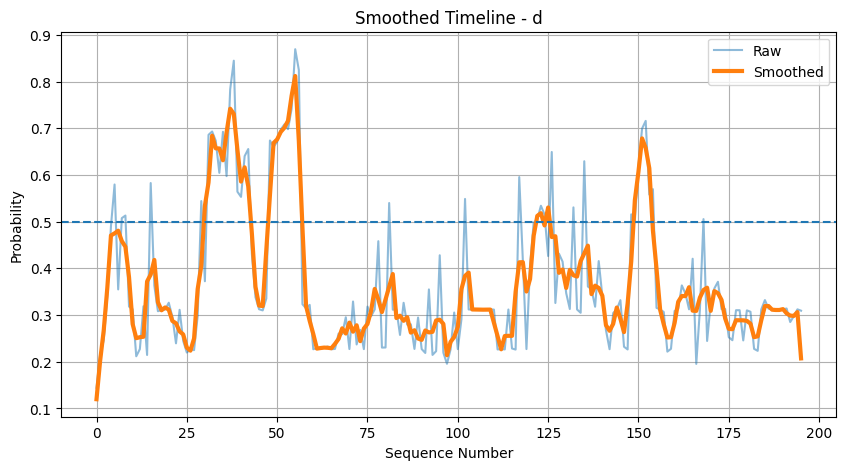

In [44]:
## smoothed timeline
window = 3

smooth_probs = np.convolve(
    probs,
    np.ones(window)/window,
    mode='same'
)

plt.figure(figsize=(10,5))

plt.plot(probs, alpha=0.5, label="Raw")
plt.plot(smooth_probs, linewidth=3, label="Smoothed")
plt.axhline(0.5, linestyle='--')

plt.title(f"Smoothed Timeline - {person_name}")
plt.xlabel("Sequence Number")
plt.ylabel("Probability")

plt.legend()
plt.grid(True)
plt.show()

In [37]:
### evaluate all test persons
all_true = []
all_pred = []
all_prob = []

for person in test_persons:

    X, y, probs, preds = predict_person(person)

    all_true.extend(y)
    all_pred.extend(preds)
    all_prob.extend(probs)

print("Total Tested Sequences:", len(all_true))

43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step
Total Tested Sequences: 1929


In [38]:
### metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", round(accuracy_score(all_true, all_pred),4))
print("Precision:", round(precision_score(all_true, all_pred),4))
print("Recall   :", round(recall_score(all_true, all_pred),4))
print("F1 Score :", round(f1_score(all_true, all_pred),4))
print("ROC AUC  :", round(roc_auc_score(all_true, all_prob),4))

Accuracy : 0.7553
Precision: 0.8545
Recall   : 0.6211
F1 Score : 0.7194
ROC AUC  : 0.8472


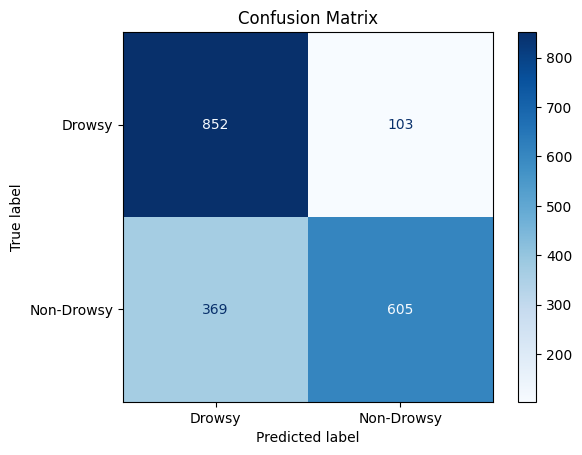

In [39]:
## confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_true, all_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Drowsy","Non-Drowsy"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [40]:
### per person accuracy
for person in test_persons:

    X, y, probs, preds = predict_person(person)

    acc = accuracy_score(y, preds)

    print(person, "Accuracy =", round(acc,4))

43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step
X Accuracy = 0.9128
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step
I Accuracy = 0.7824
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step
D Accuracy = 0.3824
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step
A Accuracy = 1.0
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step
U Accuracy = 0.939
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step
d Accuracy = 0.2194
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step
x Accuracy = 0.3496
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step
i Accuracy = 0.9317
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step
a Accuracy = 0.8016
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step
u Accuracy = 0.94


### visualization


In [52]:
person_name = list(test_persons.keys())[6]

X, y, probs, preds = predict_person(person_name)

print("Selected Person:", person_name)
print("Total Sequences:", len(y))

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step
Selected Person: x
Total Sequences: 226


In [54]:
true_drowsy = []
true_non = []
wrong_drowsy = []
wrong_non = []

for i in range(len(y)):

    # Actual Drowsy + Predicted Drowsy
    if y[i] == 0 and preds[i] == 0:
        true_drowsy.append(i)

    # Actual Non + Predicted Non
    elif y[i] == 1 and preds[i] == 1:
        true_non.append(i)

    # Actual Drowsy + Predicted Non
    elif y[i] == 0 and preds[i] == 1:
        wrong_drowsy.append(i)

    # Actual Non + Predicted Drowsy
    elif y[i] == 1 and preds[i] == 0:
        wrong_non.append(i)

print("True Drowsy      :", len(true_drowsy))
print("True Non-Drowsy  :", len(true_non))
print("Wrong Drowsy     :", len(wrong_drowsy))
print("Wrong Non-Drowsy :", len(wrong_non))

True Drowsy      : 0
True Non-Drowsy  : 79
Wrong Drowsy     : 0
Wrong Non-Drowsy : 147


In [55]:
def show_sequence_grid(indices, title_text):

    n = min(5, len(indices))

    for k in range(n):

        idx = indices[k]

        plt.figure(figsize=(15,3))

        for j in range(10):

            plt.subplot(2,5,j+1)
            plt.imshow(X[idx][j])
            plt.axis("off")

        plt.suptitle(
            f"{title_text} | Seq {idx} | Prob={probs[idx]:.3f}",
            fontsize=14
        )

        plt.tight_layout()
        plt.show()

In [56]:
show_sequence_grid(
    true_drowsy,
    "TRUE DROWSY"
)

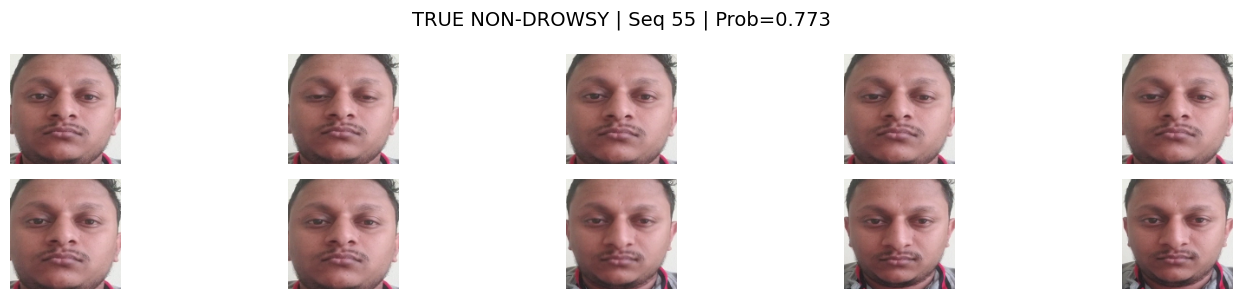

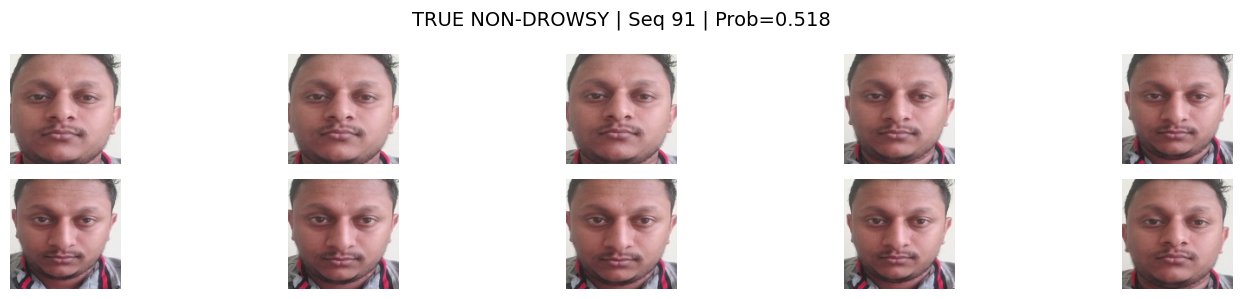

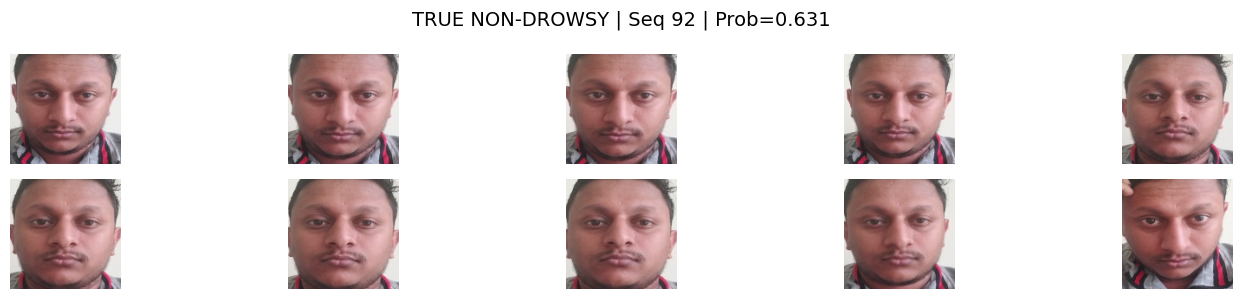

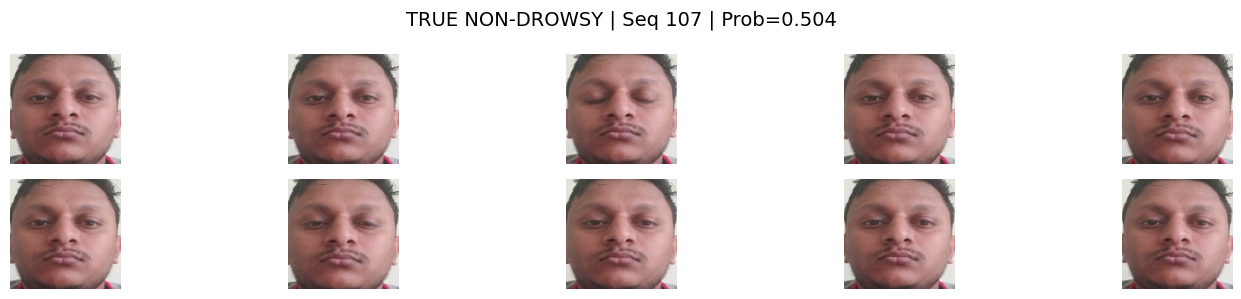

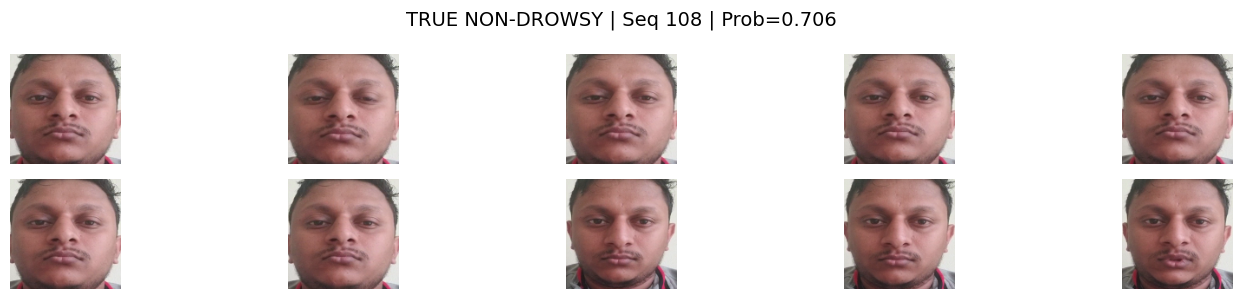

In [57]:
show_sequence_grid(
    true_non,
    "TRUE NON-DROWSY"
)

In [58]:
show_sequence_grid(
    wrong_drowsy,
    "WRONG DROWSY"
)

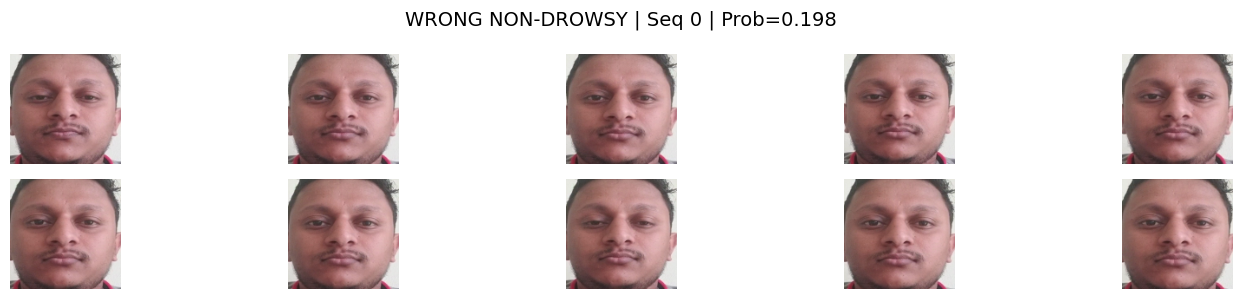

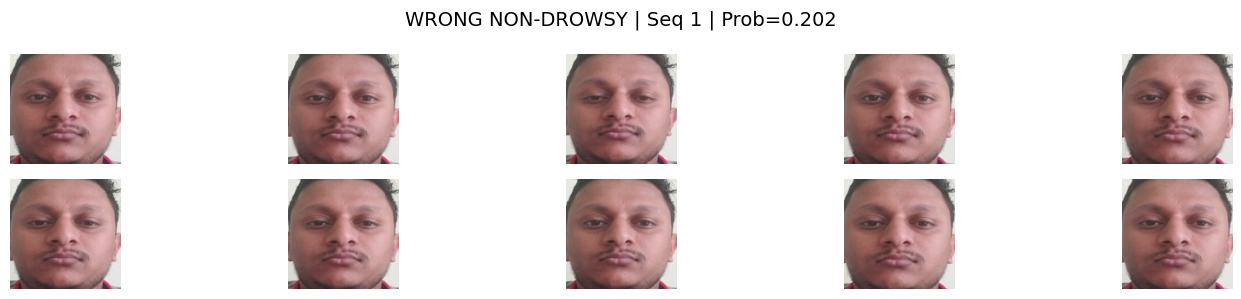

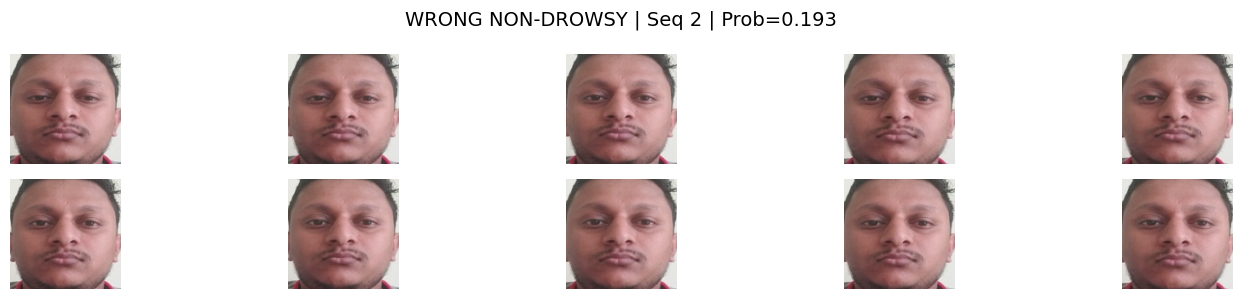

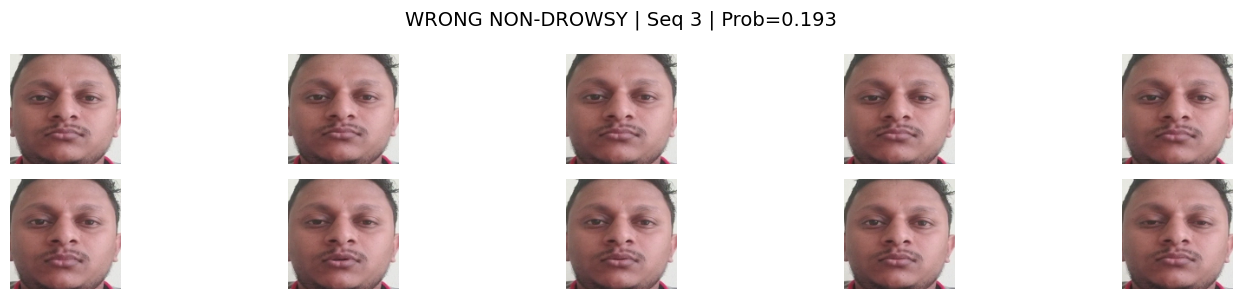

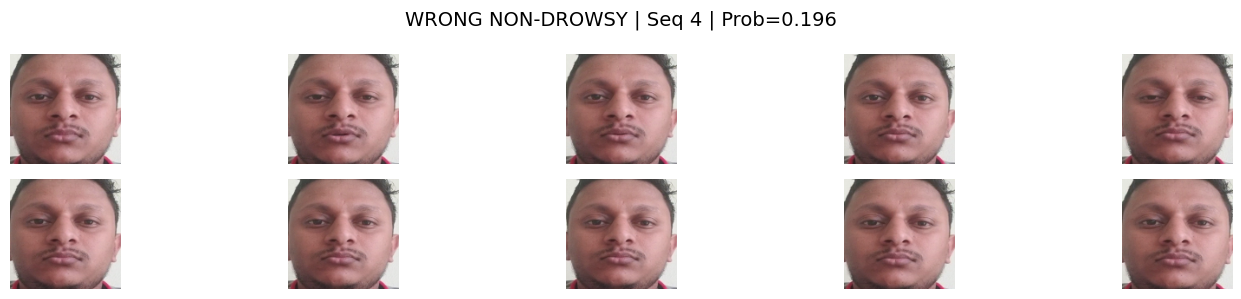

In [59]:
show_sequence_grid(
    wrong_non,
    "WRONG NON-DROWSY"
)

### cnn+bidirectional-lstm

In [140]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    TimeDistributed,
    GlobalAveragePooling2D,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [92]:
# import new layers
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Bidirectional
)

from tensorflow.keras.applications import MobileNetV2

print("Bi-LSTM layers imported.")

Bi-LSTM layers imported.


In [93]:


# CNN + BiLSTM Model
model_bilstm = Sequential()

# ----- Frame-wise CNN -----
model_bilstm.add(
    TimeDistributed(
        Conv2D(32, (3,3), activation='relu', padding='same'),
        input_shape=(SEQ_LEN, 128, 128, 3)
    )
)

model_bilstm.add(
    TimeDistributed(
        MaxPooling2D((2,2))
    )
)

model_bilstm.add(
    TimeDistributed(
        Conv2D(64, (3,3), activation='relu', padding='same')
    )
)

model_bilstm.add(
    TimeDistributed(
        MaxPooling2D((2,2))
    )
)

model_bilstm.add(
    TimeDistributed(
        Conv2D(128, (3,3), activation='relu', padding='same')
    )
)

model_bilstm.add(
    TimeDistributed(
        MaxPooling2D((2,2))
    )
)

model_bilstm.add(
    TimeDistributed(
        Flatten()
    )
)

# ----- Bidirectional LSTM -----
model_bilstm.add(
    Bidirectional(
        LSTM(
            32,
            return_sequences=False
        )
    )
)

# ----- Classifier -----
model_bilstm.add(Dropout(0.6))

model_bilstm.add(
    Dense(1, activation='sigmoid')
)

# Compile
model_bilstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_bilstm.summary()

/home/anirbannayak/DL_PROJECT/dl-venv/lib/python3.10/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_13             │ (None, 10, 128, 128,   │           896 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_14             │ (None, 10, 64, 64, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_15             │ (None, 10, 64, 64, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_16             │ (None, 10, 32, 32, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_17             │ (None, 10, 32, 32,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_18             │ (None, 10, 16, 16,     │             0 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_19             │ (None, 10, 32768)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 64)             │     8,397,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,490,369 (32.39 MB)

 Trainable params: 8,490,369 (32.39 MB)

 Non-trainable params: 0 (0.00 B)

In [94]:
### call backs
early_stop_bi = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

# checkpoint_bi = tf.keras.callbacks.ModelCheckpoint(
#     "best_bilstm.h5",
#     monitor='val_loss',
#     save_best_only=True
# )

reduce_lr_bi = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

print("Callbacks ready.")

Callbacks ready.


In [96]:
history_bi = model_bilstm.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[
        early_stop_bi,
        # checkpoint_bi,
        reduce_lr_bi
    ]
)

Epoch 1/25
602/602 ━━━━━━━━━━━━━━━━━━━━ 1110s 2s/step - accuracy: 0.9728 - loss: 0.0762 - val_accuracy: 0.6905 - val_loss: 1.8438 - learning_rate: 0.0010
Epoch 2/25
602/602 ━━━━━━━━━━━━━━━━━━━━ 1118s 2s/step - accuracy: 0.9960 - loss: 0.0117 - val_accuracy: 0.6858 - val_loss: 1.5935 - learning_rate: 0.0010
Epoch 3/25
602/602 ━━━━━━━━━━━━━━━━━━━━ 1118s 2s/step - accuracy: 0.9965 - loss: 0.0127 - val_accuracy: 0.6851 - val_loss: 2.0030 - learning_rate: 0.0010
Epoch 4/25
602/602 ━━━━━━━━━━━━━━━━━━━━ 1120s 2s/step - accuracy: 0.9719 - loss: 0.0745 - val_accuracy: 0.6750 - val_loss: 1.6579 - learning_rate: 0.0010
Epoch 5/25
602/602 ━━━━━━━━━━━━━━━━━━━━ 1119s 2s/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.7655 - val_loss: 1.1190 - learning_rate: 0.0010
Epoch 6/25
602/602 ━━━━━━━━━━━━━━━━━━━━ 1122s 2s/step - accuracy: 1.0000 - loss: 4.2230e-04 - val_accuracy: 0.7534 - val_loss: 1.4954 - learning_rate: 0.0010
Epoch 7/25
602/602 ━━━━━━━━━━━━━━━━━━━━ 1121s 2s/step - accuracy: 0.9952

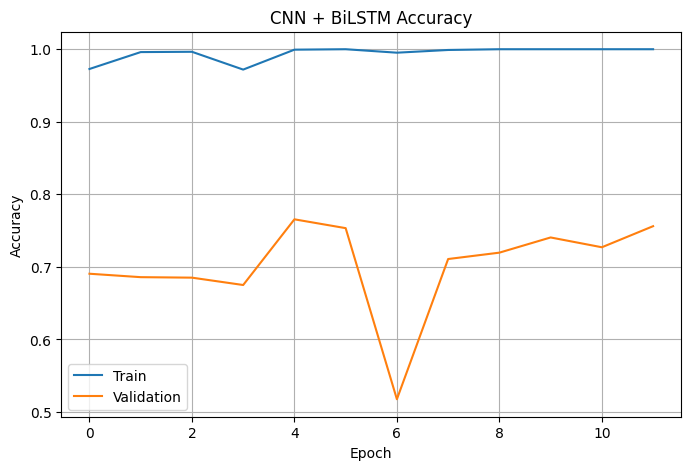

In [98]:
plt.figure(figsize=(8,5))

plt.plot(
    history_bi.history['accuracy'],
    label='Train'
)

plt.plot(
    history_bi.history['val_accuracy'],
    label='Validation'
)

plt.title("CNN + BiLSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

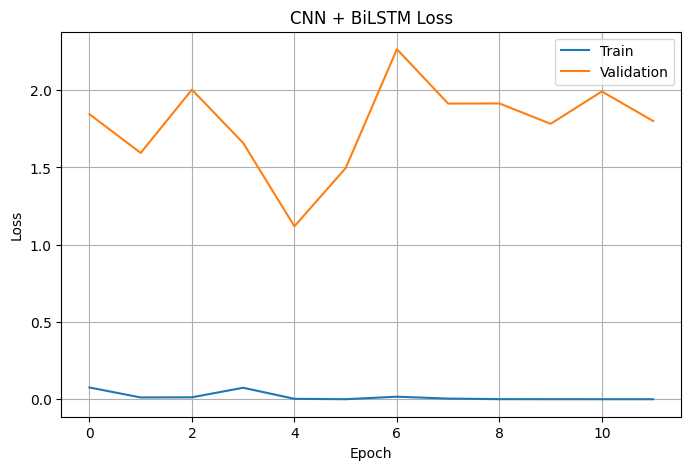

In [99]:
plt.figure(figsize=(8,5))

plt.plot(
    history_bi.history['loss'],
    label='Train'
)

plt.plot(
    history_bi.history['val_loss'],
    label='Validation'
)

plt.title("CNN + BiLSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### testing

In [100]:
def predict_person_bilstm(person):

    seq_data = test_persons[person]

    X = []
    y = []

    for seq_paths, label in seq_data:

        frames = []

        for path in seq_paths:
            frames.append(load_image(path))

        X.append(frames)
        y.append(label)

    X = np.array(X)
    y = np.array(y)

    probs = model_bilstm.predict(
        X,
        batch_size=32,
        verbose=0
    ).flatten()

    preds = (probs > 0.5).astype(int)

    return X, y, probs, preds

print("Prediction function ready.")

Prediction function ready.


In [135]:
person_name = list(test_persons.keys())[7]

X, y, probs, preds = predict_person_bilstm(person_name)

print("Selected Person:", person_name)
print("Sequences:", len(y))

Selected Person: i
Sequences: 205


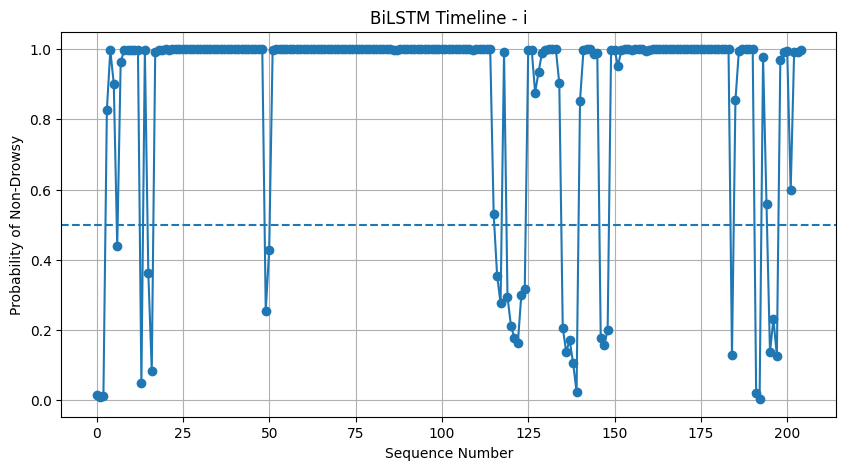

In [136]:
plt.figure(figsize=(10,5))

plt.plot(probs, marker='o')
plt.axhline(0.5, linestyle='--')

plt.title(f"BiLSTM Timeline - {person_name}")
plt.xlabel("Sequence Number")
plt.ylabel("Probability of Non-Drowsy")

plt.grid(True)
plt.show()

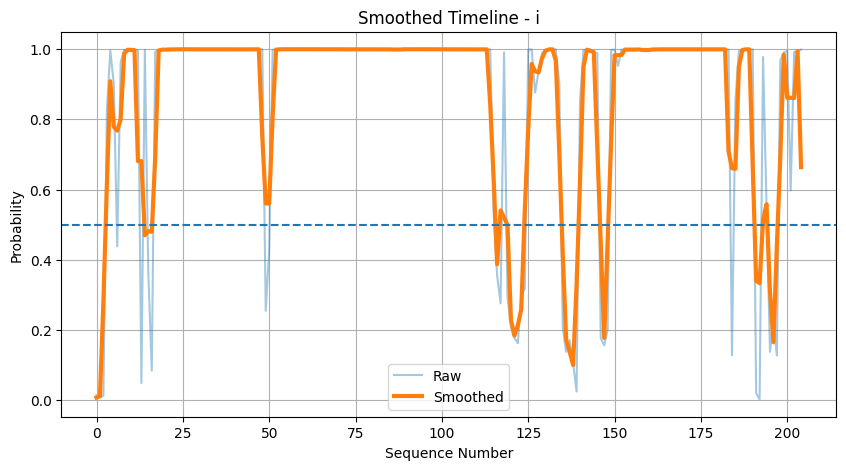

In [137]:
window = 3

smooth = np.convolve(
    probs,
    np.ones(window)/window,
    mode='same'
)

plt.figure(figsize=(10,5))

plt.plot(probs, alpha=0.4, label='Raw')
plt.plot(smooth, linewidth=3, label='Smoothed')
plt.axhline(0.5, linestyle='--')

plt.title(f"Smoothed Timeline - {person_name}")
plt.xlabel("Sequence Number")
plt.ylabel("Probability")

plt.legend()
plt.grid(True)
plt.show()

In [139]:
all_true = []
all_pred = []
all_prob = []

for person in test_persons:

    Xp, yp, probp, predp = predict_person_bilstm(person)

    all_true.extend(yp)
    all_pred.extend(predp)
    all_prob.extend(probp)

print("Total Tested Sequences:", len(all_true))

Total Tested Sequences: 1929


In [124]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", round(accuracy_score(all_true, all_pred),4))
print("Precision:", round(precision_score(all_true, all_pred),4))
print("Recall   :", round(recall_score(all_true, all_pred),4))
print("F1 Score :", round(f1_score(all_true, all_pred),4))
print("ROC AUC  :", round(roc_auc_score(all_true, all_prob),4))

Accuracy : 0.5666
Precision: 0.6302
Recall   : 0.3429
F1 Score : 0.4441
ROC AUC  : 0.5305


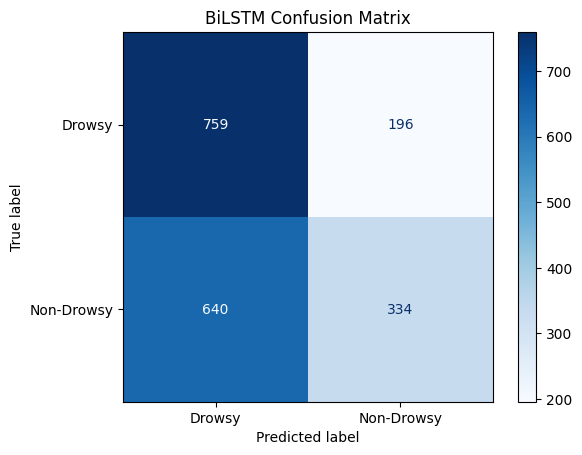

In [125]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_true, all_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Drowsy","Non-Drowsy"]
)

disp.plot(cmap="Blues")
plt.title("BiLSTM Confusion Matrix")
plt.show()

In [113]:
for person in test_persons:

    Xp, yp, probp, predp = predict_person_bilstm(person)

    acc = accuracy_score(yp, predp)

    print(person, "Accuracy =", round(acc,4))

X Accuracy = 0.7297
I Accuracy = 0.8796
D Accuracy = 0.6176
A Accuracy = 0.9319
U Accuracy = 0.4512
d Accuracy = 0.3112
x Accuracy = 0.0088
i Accuracy = 0.8488
a Accuracy = 0.0
u Accuracy = 0.97


In [126]:
true_drowsy = []
true_non = []
wrong_drowsy = []
wrong_non = []

for i in range(len(y)):

    if y[i] == 0 and preds[i] == 0:
        true_drowsy.append(i)

    elif y[i] == 1 and preds[i] == 1:
        true_non.append(i)

    elif y[i] == 0 and preds[i] == 1:
        wrong_drowsy.append(i)

    elif y[i] == 1 and preds[i] == 0:
        wrong_non.append(i)

print("True Drowsy:", len(true_drowsy))
print("True Non:", len(true_non))
print("Wrong Drowsy:", len(wrong_drowsy))
print("Wrong Non:", len(wrong_non))

True Drowsy: 21
True Non: 0
Wrong Drowsy: 13
Wrong Non: 0


In [131]:
def show_sequences(indices, title_name):

    n = min(5, len(indices))

    for k in range(n):

        idx = indices[k]

        plt.figure(figsize=(15,3))

        for j in range(10):

            plt.subplot(2,5,j+1)
            plt.imshow(X[idx][j])
            plt.axis("off")

        plt.suptitle(
            f"{title_name} | Seq {idx} | Prob={probs[idx]:.3f}",
            fontsize=14
        )

        plt.tight_layout()
        plt.show()

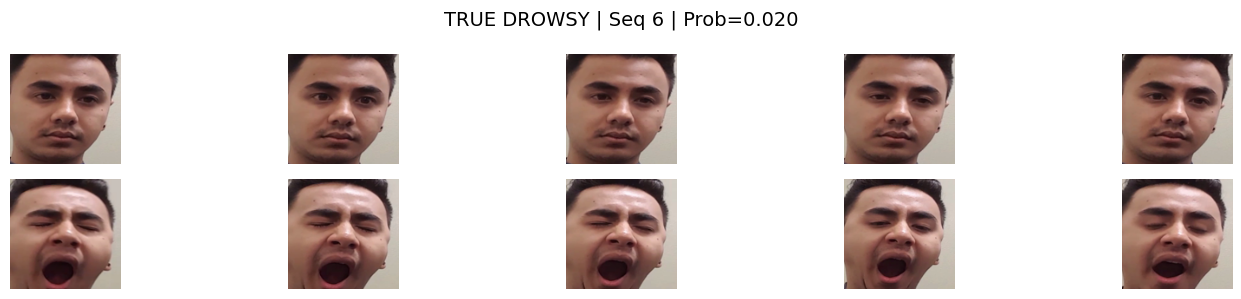

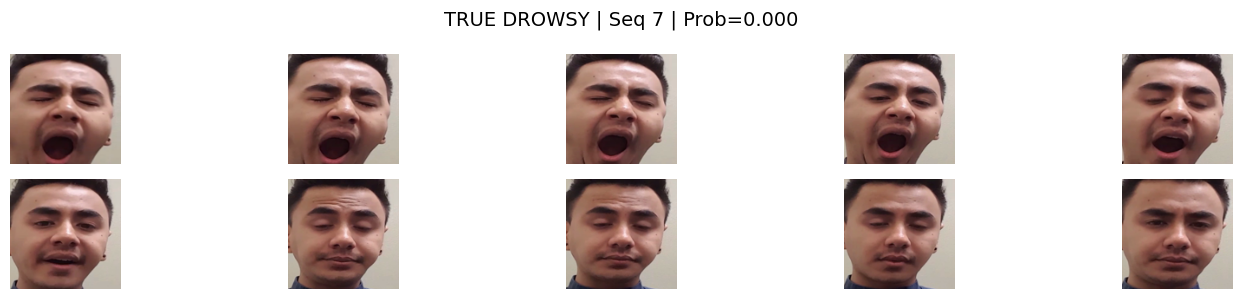

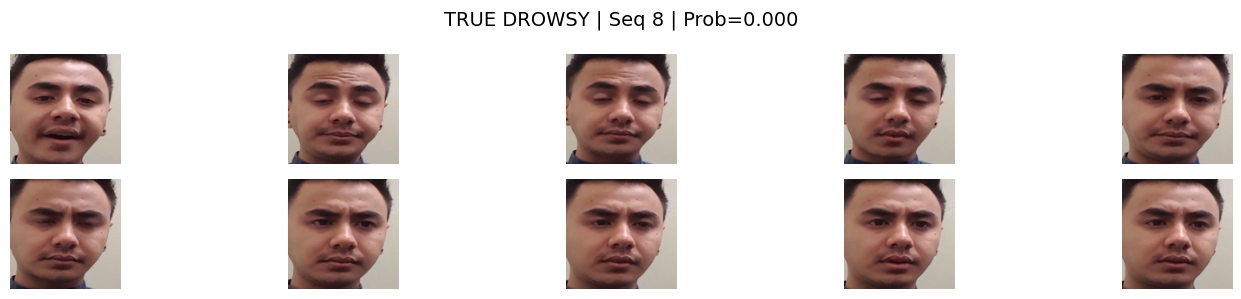

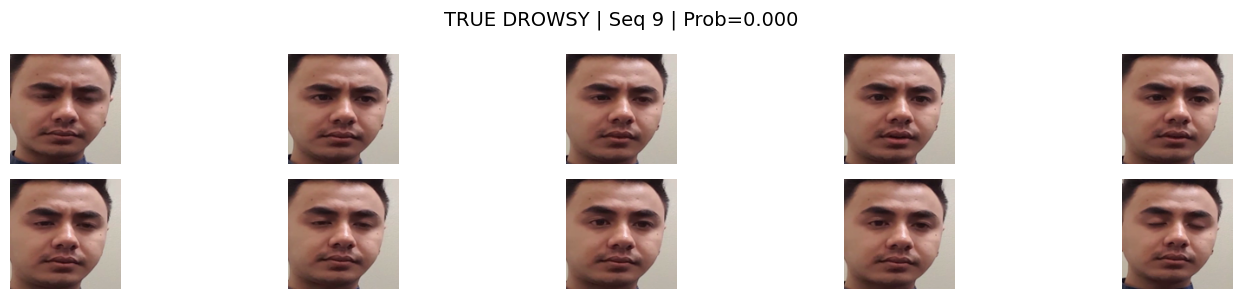

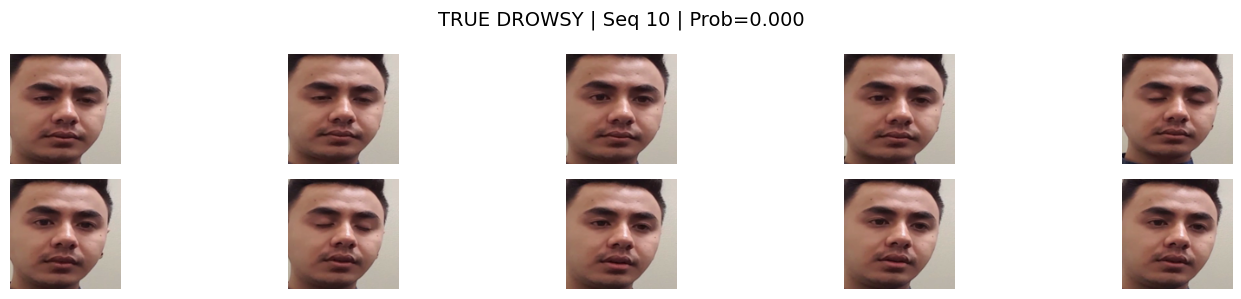

In [128]:
show_sequences(true_drowsy, "TRUE DROWSY")

In [133]:
show_sequences(true_non, "TRUE NON-DROWSY")

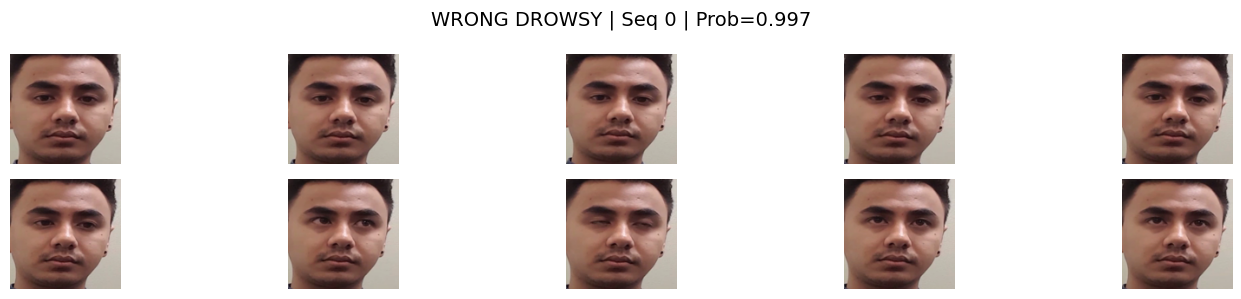

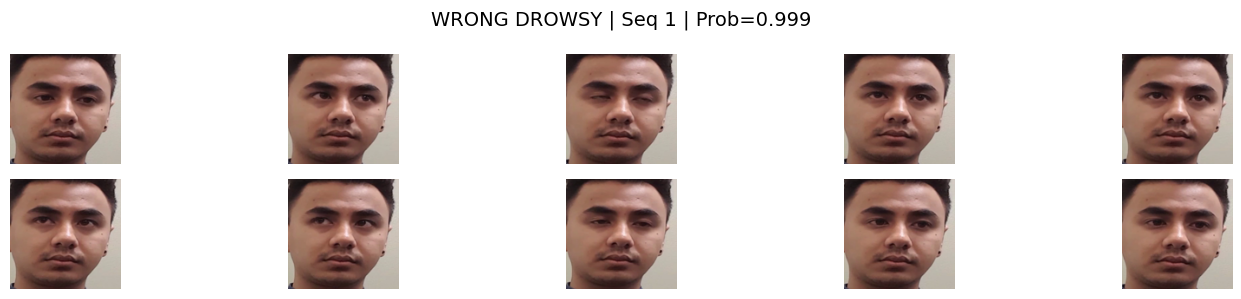

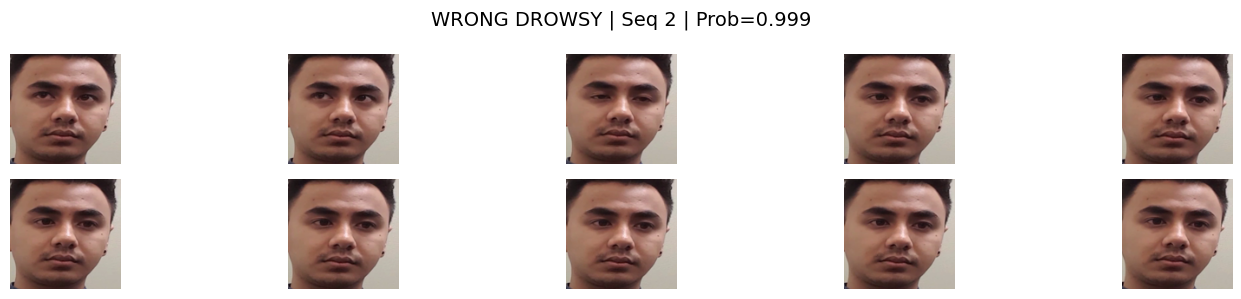

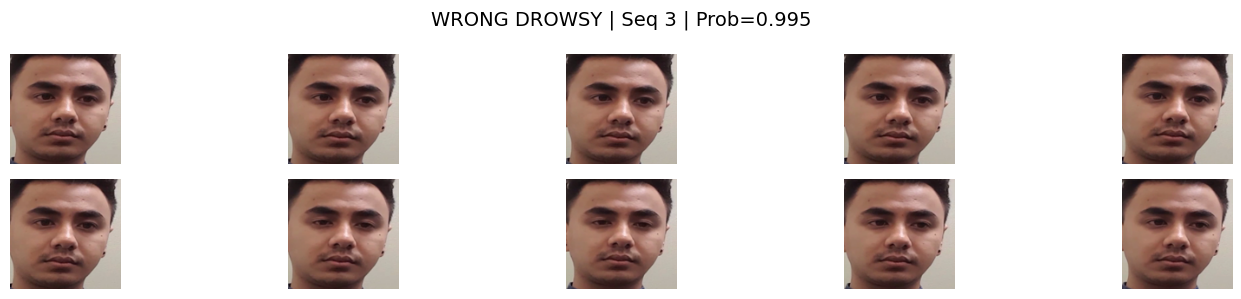

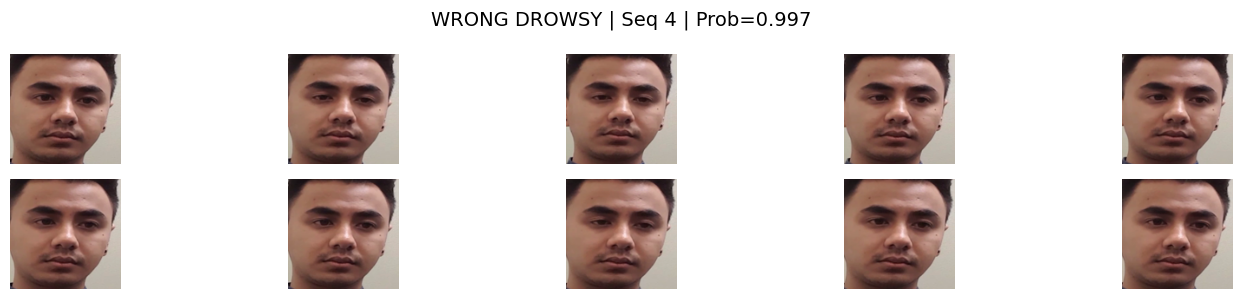

In [130]:
show_sequences(wrong_drowsy, "WRONG DROWSY")

In [132]:
show_sequences(wrong_non, "WRONG NON-DROWSY")